<a href="https://colab.research.google.com/github/firdausc/Python_CertificateGenerator/blob/main/20_Python_Certificate_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cert Generator

### Goal of this project is to:

1. `Do simple Data Analysis`
    - Deal with missing values
    - Format the date or text

2. `Enchance Python Concepts`
3. `Explore more 3rd party libraries - reportlab`

---

Before starting,

Make sure the students have the `Starting Project Template` Google Drive Folder shared to them so that they can reupload to their own drive


Explain to them the `folder structure`.

---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
##1. Download & Importing packages for this project
---

In [2]:
# install external package "reportlab" because it is not in normal python
# "reportlab" is a library to link pdf to python program

# "pip" is a python package downloader (package manager)
#  pip package manager is like ur Appstore to download apps
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.4 MB/s eta 0:00:00


#Import Library

In [3]:
import numpy as np#Numerical Python
import pandas as pd#Deal with DataFrame
from reportlab.lib.pagesizes import landscape, A4 #Deal with doc
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
from reportlab.pdfbase import pdfmetrics#Help to register the fonts
from reportlab.pdfbase.ttfonts import TTFont#To Deal Fonts

#Read the file

In [4]:
df = pd.read_excel("/content/drive/MyDrive/Certificate Generator Sat/1.2 Python Certificate Generator Project (STARTING TEMPLATE) 5/dataset.xlsx")

In [5]:
df

,Name,Course,CourseLevel,Date
0,Christy Cunningham,Python,Beginner,2023-09-10
1,Douglas Tucker,PYTHON,MASTER,2023-09-11
2,Travis Walters,Java,Intermediate,2023-09-12
3,Nathaniel Harris,Web Development,Advanced,2023-09-13
4,-,NaN,Advanced,NaT
5,Tonya Carter,AI & Machine Learning,Beginner,2023-09-14
6,Erik Smith,Mobile Development,Beginner,2023-09-15
7,Kristopher Johnson,Python,Beginner,2023-09-16
8,Jonathan Bucker,NaN,NaN,NaT
9,Robert Buck,PYTHON,Master,2023-09-17


In [6]:
#Get infomation of the dataset

df.info()

#non-null (not empty) --> 13 non-null --> none of the 13 rows are empty (there is data)

# from this info, we know that there are 4 columns and 13 rows (some of them are empty)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Name         13 non-null     object        
 1   Course       11 non-null     object        
 2   CourseLevel  12 non-null     object        
 3   Date         11 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 548.0+ bytes


---
## 3. Data Cleaning (Data analysis)

`Data cleaning` - Formatting the data before doing the certificate generator logic

- Deal with missing values
- Format the date or text

---

In [ ]:
# the 3 problems with the original dataset (raw excel file)

# 1. Inconsistency formatting in "Course" & "CourseLevel" columns - (some are capitalized but some are uppercase)
# 2. Date format (yyyy/mm/dd) --> we want to change into (xq/mm/yyyy)
# 3. Empty rows (half empty row 4 & 8)

# we are going to solve these problems using Data analysis with Pandas!

In [7]:
#Problem No 3 -> Missing Data
# drop all the rows that have AT LEAST 1 empty column

df = df.dropna()


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 12
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Name         11 non-null     object        
 1   Course       11 non-null     object        
 2   CourseLevel  11 non-null     object        
 3   Date         11 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 440.0+ bytes


In [9]:
df

,Name,Course,CourseLevel,Date
0,Christy Cunningham,Python,Beginner,2023-09-10
1,Douglas Tucker,PYTHON,MASTER,2023-09-11
2,Travis Walters,Java,Intermediate,2023-09-12
3,Nathaniel Harris,Web Development,Advanced,2023-09-13
5,Tonya Carter,AI & Machine Learning,Beginner,2023-09-14
6,Erik Smith,Mobile Development,Beginner,2023-09-15
7,Kristopher Johnson,Python,Beginner,2023-09-16
9,Robert Buck,PYTHON,Master,2023-09-17
10,Joseph Mcdonald,Java,Intermediate,2023-09-18
11,Jerome Abbott,Web Development,Advanced,2023-09-19


In [10]:
# Problem 2:  Date format (yyyy/mm/dd) --> we want to change into (dd/mm/yyyy)

df['Date']
# this gives us the "Date" column in pandas Series
# Date format (yyyy/mm/dd) --> we want to change into (dd/mm/yyyy)

,Date
0,2023-09-10
1,2023-09-11
2,2023-09-12
3,2023-09-13
5,2023-09-14
6,2023-09-15
7,2023-09-16
9,2023-09-17
10,2023-09-18
11,2023-09-19


In [11]:
#Lets take a look at the first row of the date

#iloc -->Index Location
df['Date'].iloc[0]

# .iloc[0] --> index location of 0 (the first row)
# Timestamp is a data type to represent time in (excel, df)
# For example, we need to change  Timestamp('2023-09-10 00:00:00') --> "10/09/2023"

Timestamp('2023-09-10 00:00:00')

In [12]:
# create a new column called "Formatted Date", and create a new date format based off of "Date" column
# then remove "Date" column

df['FormattedDate'] = df['Date'].dt.strftime("%d/%m/%Y")#Converting the format and the data type


/tmp/ipykernel_5855/1072079569.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FormattedDate'] = df['Date'].dt.strftime("%d/%m/%Y")#Converting the format and the data type


In [13]:
df['FormattedDate']

,FormattedDate
0,10/09/2023
1,11/09/2023
2,12/09/2023
3,13/09/2023
5,14/09/2023
6,15/09/2023
7,16/09/2023
9,17/09/2023
10,18/09/2023
11,19/09/2023


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 12
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Name           11 non-null     object        
 1   Course         11 non-null     object        
 2   CourseLevel    11 non-null     object        
 3   Date           11 non-null     datetime64[ns]
 4   FormattedDate  11 non-null     object        
dtypes: datetime64[ns](1), object(4)
memory usage: 528.0+ bytes


In [15]:
df.head()

,Name,Course,CourseLevel,Date,FormattedDate
0,Christy Cunningham,Python,Beginner,2023-09-10,10/09/2023
1,Douglas Tucker,PYTHON,MASTER,2023-09-11,11/09/2023
2,Travis Walters,Java,Intermediate,2023-09-12,12/09/2023
3,Nathaniel Harris,Web Development,Advanced,2023-09-13,13/09/2023
5,Tonya Carter,AI & Machine Learning,Beginner,2023-09-14,14/09/2023


In [16]:
# remove the "Date" column (because it is useless to us)

df = df.drop("Date",axis = 1)

# axis 0 = row
# axis 1 = column
# we are dropping the "Date" column

In [ ]:
df.head()

,Name,Course,CourseLevel,FormattedDate
0,Christy Cunningham,Python,Beginner,10/09/2023
1,Douglas Tucker,Python,Master,11/09/2023
2,Travis Walters,Java,Intermediate,12/09/2023
3,Nathaniel Harris,Web development,Advanced,13/09/2023
5,Tonya Carter,Ai & machine learning,Beginner,14/09/2023


In [17]:
# Problem 1: Inconsistency formatting in "Course" & "CourseLevel" columns - (some are capitalized but some are uppercase)

df['Course'] = df['Course'].str.capitalize()
df['CourseLevel'] = df['CourseLevel'].str.capitalize()

In [18]:
df

,Name,Course,CourseLevel,FormattedDate
0,Christy Cunningham,Python,Beginner,10/09/2023
1,Douglas Tucker,Python,Master,11/09/2023
2,Travis Walters,Java,Intermediate,12/09/2023
3,Nathaniel Harris,Web development,Advanced,13/09/2023
5,Tonya Carter,Ai & machine learning,Beginner,14/09/2023
6,Erik Smith,Mobile development,Beginner,15/09/2023
7,Kristopher Johnson,Python,Beginner,16/09/2023
9,Robert Buck,Python,Master,17/09/2023
10,Joseph Mcdonald,Java,Intermediate,18/09/2023
11,Jerome Abbott,Web development,Advanced,19/09/2023


# 4. Registering Fonts into our Project

In [21]:
fonts_path = "/content/drive/MyDrive/Certificate Generator Sat/1.2 Python Certificate Generator Project (STARTING TEMPLATE) 5/fonts"

# Defining the path to the fonts folder (it is like storing a string inside 'fonts_path' variable)

In [22]:
# registering 2 fonts into this project

# pdfmetrics is 1 of the packages we imported! (this package is used to register fonts so that we can use it with pdf files)

# .ttf is an entension for fonts file

# one of the commands in pdfmetrics is --> registerFont()

# TTFont() is another package we imported!

# TTFont() will need 2 inputs
# 1st input --> what font are u registering?
# 2nd input --> where is the file of the font (concat the "fonts folder" with the file )

#Bold -> We use for the header
#Regular -> Normal text

pdfmetrics.registerFont(TTFont('Lora-Bold',fonts_path + "/Lora-Bold.ttf"))
pdfmetrics.registerFont(TTFont('Lora-Regular', fonts_path + "/Lora-Regular.ttf" ))

In [ ]:
#after registering, we can use these fonts in the project later!

## 5. Creating Certificate Logic Function

---
### Version 1 of the Function

- have `checkpoints` with the students and `use the function from time to time`
- when the function is used, ask students to check their `certificates` folder in google drive (refresh a few times)


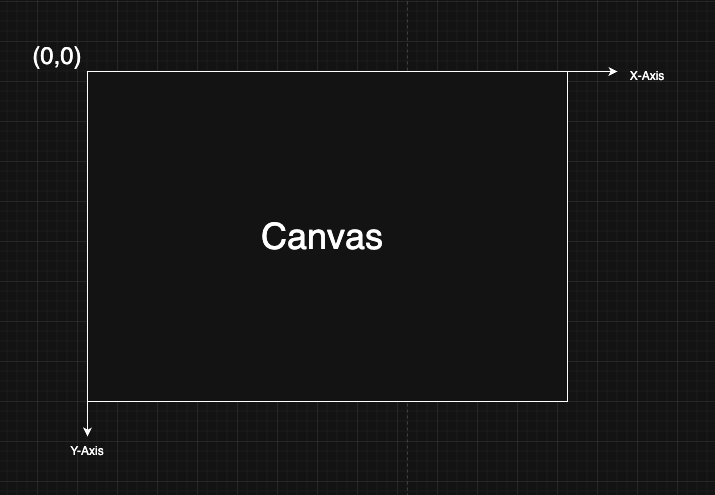

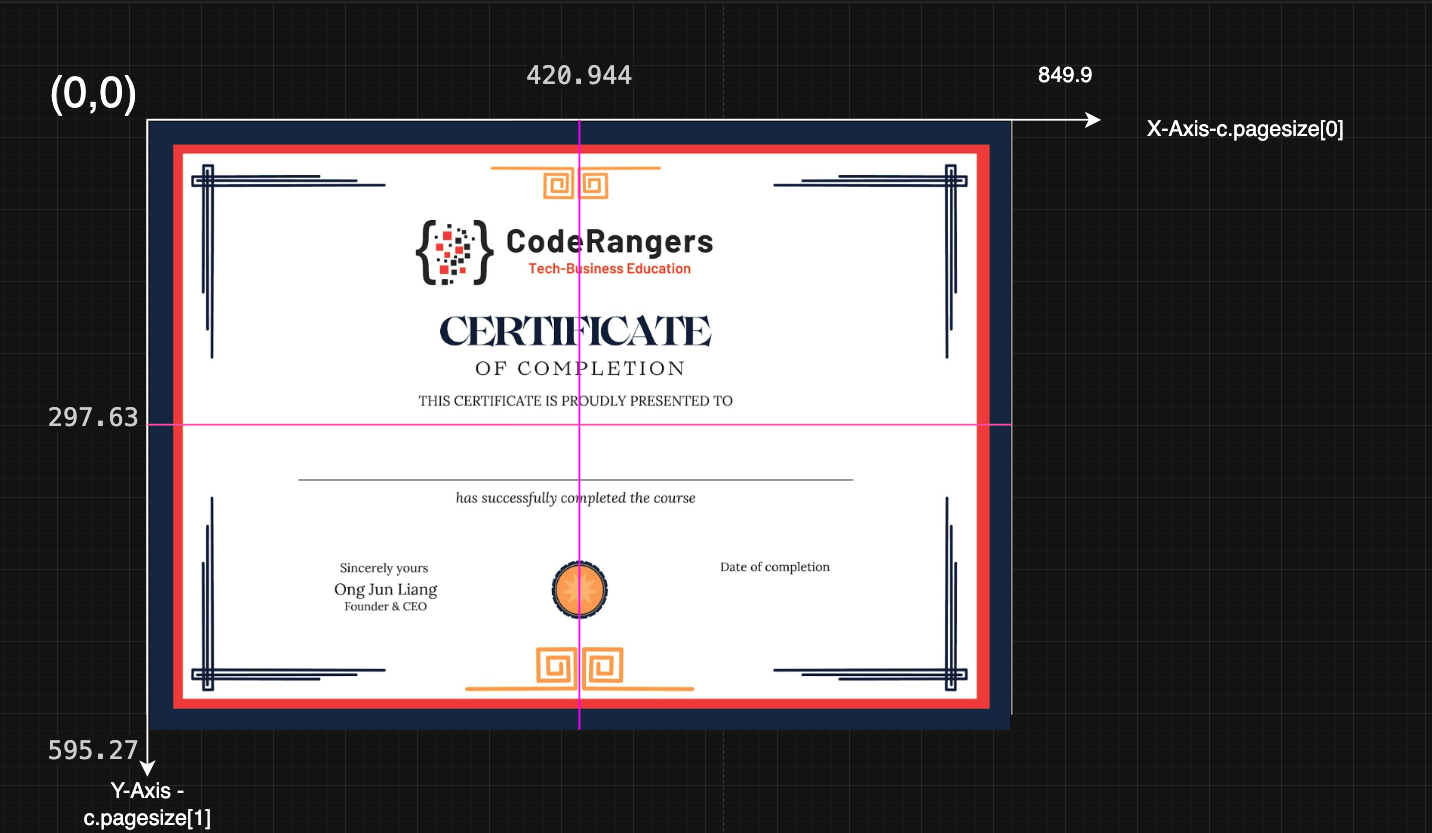

In [23]:
def certificate_generator(name,courseName,courseLevel,date):
  # store the generated file name inside a variable "pdf_file_name"
  # For example, when using this function (to create Christy Cunningham's cert) --> ChristyCunningham-python-beginner.pdf
  pdf_file_name = "/content/drive/MyDrive/Certificate Generator Sat/1.2 Python Certificate Generator Project (STARTING TEMPLATE) 5/Certificate/" + name + "-" + courseName + "-" + courseLevel + ".pdf"

  # canvas = blank screen (A4 landscape size)
  # we are storing this canvas inside this .pdf (file path --> "pdf_file_name")

  # pagesize = landscape(A4) --> making it an A4 paper landscape canvas
  # storing it inside a variable called 'c'

  # Canvas() will need 2 inputs
  # 1st input - where are you storing it?  and the file name
  # 2nd input - what size?

  c = canvas.Canvas(pdf_file_name,pagesize=landscape(A4))

  template = "/content/drive/MyDrive/Certificate Generator Sat/1.2 Python Certificate Generator Project (STARTING TEMPLATE) 5/certificate_template.jpg"

  #.drawImage -> drawImage is used to draw the certificate on the blank canvas
  # 1st input --> image --> what are u drawing on the empty canvas?? --> certifcate template
  # 2nd input --> x axis (coordinate 0)
  # 3rd input --> y axis (coodinate 0)
  # 4th input --> width --> A4[1] (using the A4 variable we imported)(where to start drawing)
  # 5th input --> height --> A4[0] (using the A4 variable we imported)(where to start drawing)
  # A4[0] --> standard A4 height
  # A4[1] --> standard A4 width

  c.drawImage(template,0,0,A4[1],A4[0])

  # Let's calculate the center of the A4 lanscape page
  # middle of the A4 page (width) --> middle because /2
  center_x = c._pagesize[0]/2

  #crosscheck by prining --> Later we will remove this code
  #print("Full width of the A4: ",c._pagesize[0])#Full width of the A4 canvas size
  #print("Center of the A4(X-Axis): ",center_x)


  # middle of the A4 page (height) --> middle because /2
  center_y = c._pagesize[1] / 2

  #print("Full width of the A4: ",c._pagesize[1])#Full height of the A4 canvas size
  #print("Center of the A4(X-Axis): ",center_y)# center A4 canvas size (y-axis)

  # 1. Name
  c.setFont('Lora-Bold',30)
  c.drawCentredString(center_x,center_y-46,name)#Input 1 : X coordinate,Input 2:Y coordinate , Input 3 : name

  # 2. CourseName & CourseLevel
  c.setFont('Lora-Bold',28)
  c.drawCentredString(center_x,center_y-105,courseName + "-" + courseLevel)

  #3. Date
  c.setFont('Lora-Bold',20)
  c.drawCentredString(center_x+192, center_y-170, date)

  # 4. Cert ID (Check cell below before coding this)
  cert_id = "Cert ID :" + str(pd.Timestamp.now().timestamp()).replace(".","")
  c.setFont('Lora-Regular',12)
  c.drawCentredString(center_x + 266, center_y - 230 , cert_id.upper())

  c.save()


In [24]:
# certificate_generator function needs 4 inputs --> (name,courseName,courseLevel,date)

certificate_generator("Alvin","Python","Begineer","20/6/2024")

In [ ]:
# For CERT ID, it has to be unique, we can uniquely generate an ID based on current time (using pd.Timestamp)
print(pd.Timestamp.now())
print(pd.Timestamp.now().timestamp()) # Unix timestamp (number of seconds since January 1 1970)
print(str(pd.Timestamp.now().timestamp()).replace(".",""))


# Unix time is a way of representing a timestamp by representing the time as the number of seconds since January 1st, 1970 at 00:00:00 UTC.

2026-06-11 11:44:48.057881
1781178288.05854
1781178288058656


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 12
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           11 non-null     object
 1   Course         11 non-null     object
 2   CourseLevel    11 non-null     object
 3   FormattedDate  11 non-null     object
dtypes: object(4)
memory usage: 440.0+ bytes


In [ ]:
# there are 11 students, the idea is USING THE FUNCTION 11 TIMES (with different 4 inputs --> (name,courseName,courseLevel,date))
# use a for loop --> loop 11 times --> use function 11 times based on different 4 inputs

#Generate certificates for each row in the DataFrame (11rows)
#execute this function 11 times --> generate 11 certs


#remember you can loop through an array with a for loop
for x in ["Jun","The","Duck"]:
  print(x)

Jun
The
Duck


In [ ]:
# enumerate() keeps track of the index of each item


for index, x in enumerate(["Jun","The","Duck"]):
  print(str(index) + " " + x )

0 Jun
1 The
2 Duck


In [ ]:
# again we need to loop through the df

# but this is not how u loop through each row

# this will loop through the columns

for x in df:
  print(x)

Name
Course
CourseLevel
FormattedDate


In [ ]:
# df.iterrows gives u a loopable (array-like)
# df.iterrows gives you 2 items (index, item(row))

for index, x in df.iterrows():
    print(index)

0
1
2
3
5
6
7
9
10
11
12


In [ ]:
for index, x in df.iterrows():
    print(x)
    print('---------------------------------------')

Name             Christy Cunningham
Course                       Python
CourseLevel                Beginner
FormattedDate            10/09/2023
Name: 0, dtype: object
---------------------------------------
Name             Douglas Tucker
Course                   Python
CourseLevel             Master 
FormattedDate        11/09/2023
Name: 1, dtype: object
---------------------------------------
Name             Travis Walters
Course                     Java
CourseLevel        Intermediate
FormattedDate        12/09/2023
Name: 2, dtype: object
---------------------------------------
Name             Nathaniel Harris
Course            Web development
CourseLevel              Advanced
FormattedDate          13/09/2023
Name: 3, dtype: object
---------------------------------------
Name                      Tonya Carter
Course           Ai & machine learning
CourseLevel                   Beginner
FormattedDate               14/09/2023
Name: 5, dtype: object
---------------------------------

In [28]:
for index, x in df.iterrows():
    certificate_generator(x['Name'],x['Course'],x['CourseLevel'],x['FormattedDate'])

print((str(len(df))) + "certificates generated successfully")

11certificates generated successfully
